In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('cleanned.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,41,Female,typical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0


In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
num         0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    object 
 2   cp        918 non-null    object 
 3   trestbps  918 non-null    float64
 4   chol      918 non-null    float64
 5   fbs       918 non-null    bool   
 6   restecg   918 non-null    object 
 7   thalch    918 non-null    float64
 8   exang     918 non-null    bool   
 9   oldpeak   918 non-null    float64
 10  num       918 non-null    int64  
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 66.5+ KB


In [6]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,918.000000,918.000000,918.000000,918.000000,918.00000,918.000000
mean,53.510893,132.141612,199.862745,137.689542,0.85512,0.995643
std,9.432617,17.924706,109.154522,25.153455,1.05845,1.142985
min,28.000000,80.000000,0.000000,60.000000,-2.60000,0.000000
25%,47.000000,120.000000,177.250000,120.000000,0.00000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.50000,1.000000
75%,60.000000,140.000000,267.000000,155.750000,1.50000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.20000,4.000000


In [7]:
df.shape

(918, 11)

In [8]:
df.duplicated().sum()

np.int64(0)

C:\Users\vikas\AppData\Local\Temp\ipykernel_13288\469706240.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='num', palette='Set2')


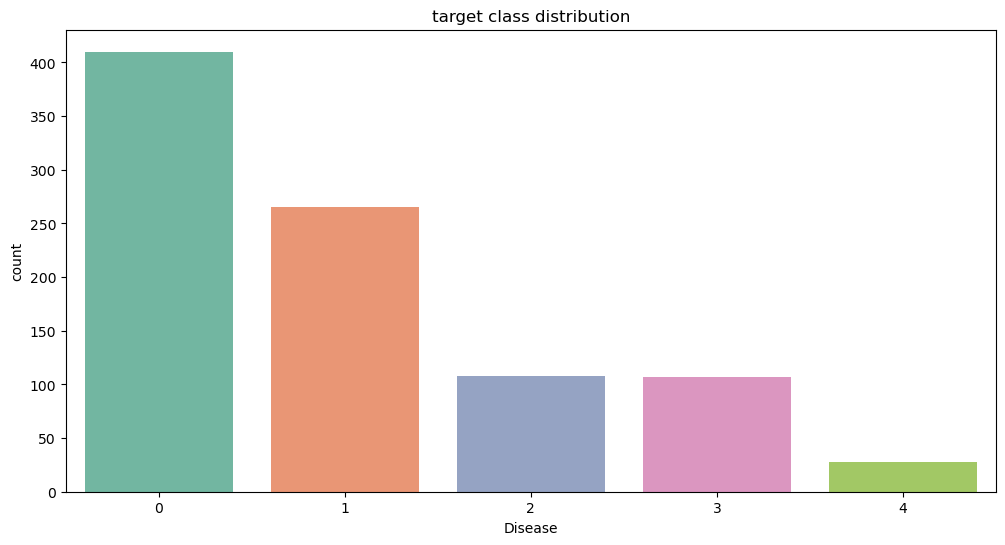

In [9]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='num', palette='Set2')
plt.title('target class distribution')
plt.xlabel('Disease')
plt.show()

In [10]:
df['num'].value_counts(normalize=True) * 100

num
0    44.662309
1    28.867102
2    11.764706
3    11.655773
4     3.050109
Name: proportion, dtype: float64

In [11]:
numeric_col=df.select_dtypes(include=['int64', 'float64']).columns

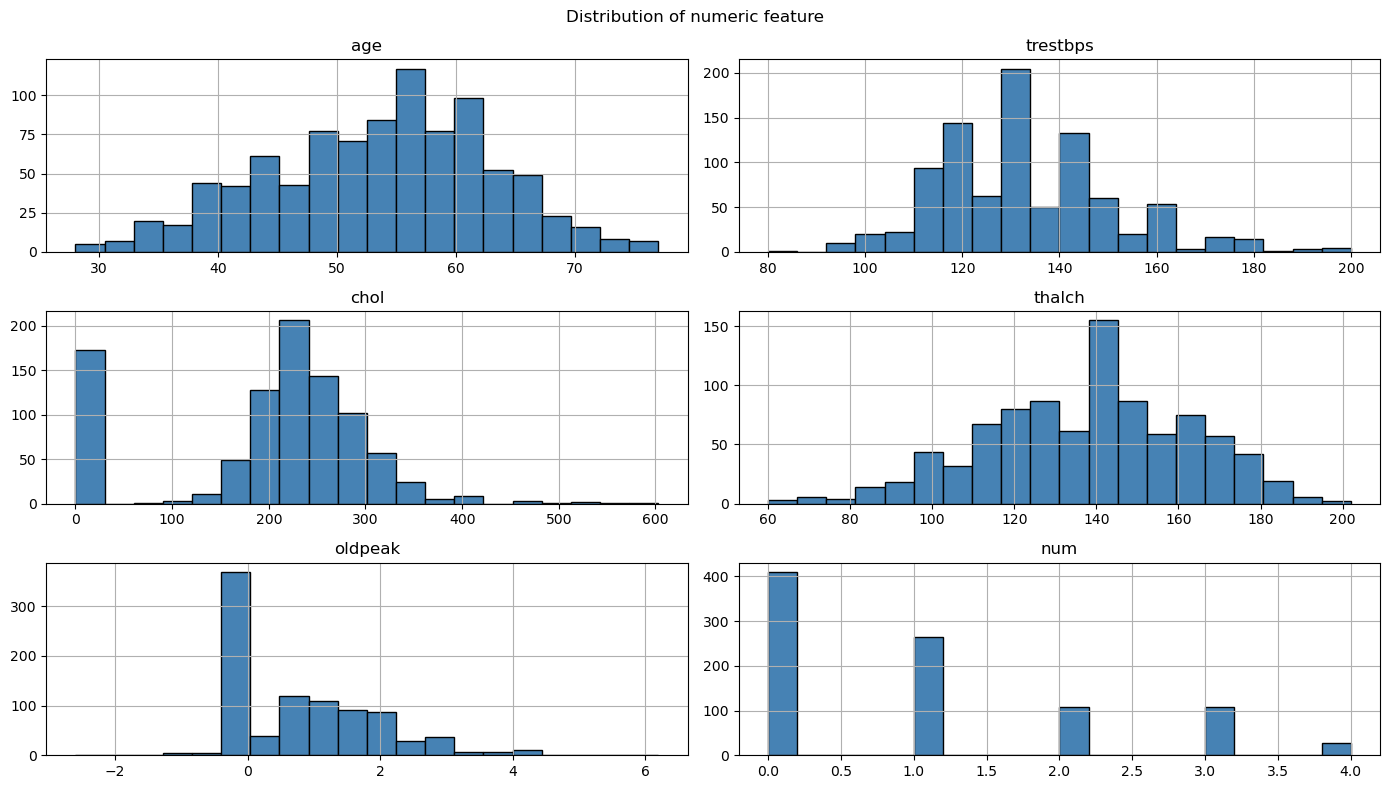

In [12]:
numeric_col=[i for i in numeric_col if i in df.columns]
df[numeric_col].hist(bins=20, figsize=(14,8), color='steelblue', edgecolor='black')
plt.suptitle('Distribution of numeric feature')
plt.tight_layout()
plt.show()

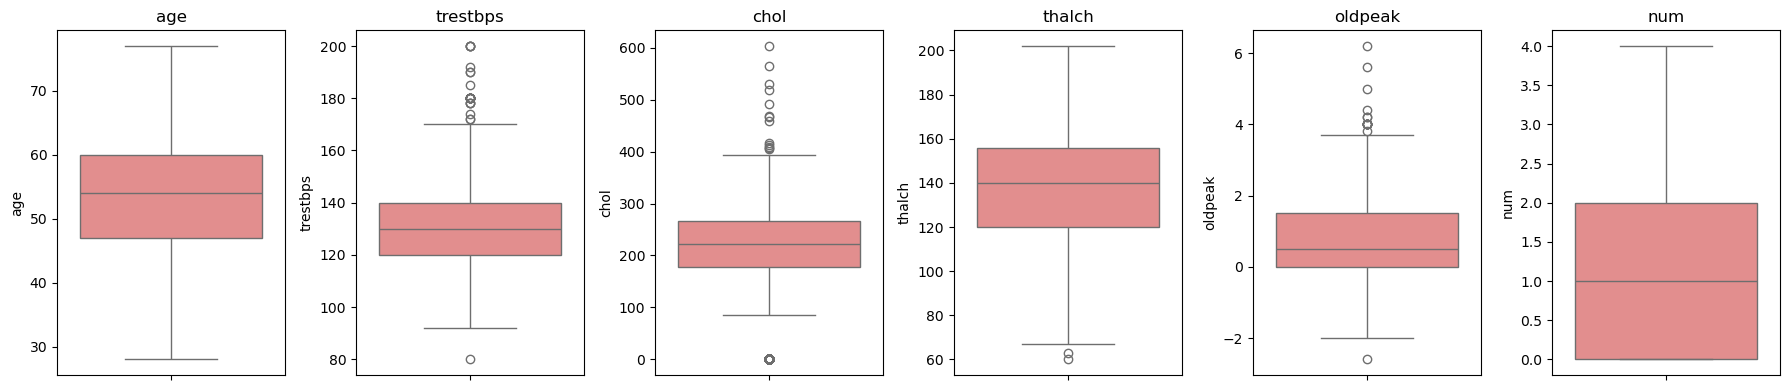

In [13]:
fig, axes=plt.subplots(1, len(numeric_col), figsize=(18,4))
for i, col in enumerate(numeric_col):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

C:\Users\vikas\AppData\Local\Temp\ipykernel_13288\1587630716.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')
C:\Users\vikas\AppData\Local\Temp\ipykernel_13288\1587630716.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')
C:\Users\vikas\AppData\Local\Temp\ipykernel_13288\1587630716.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')


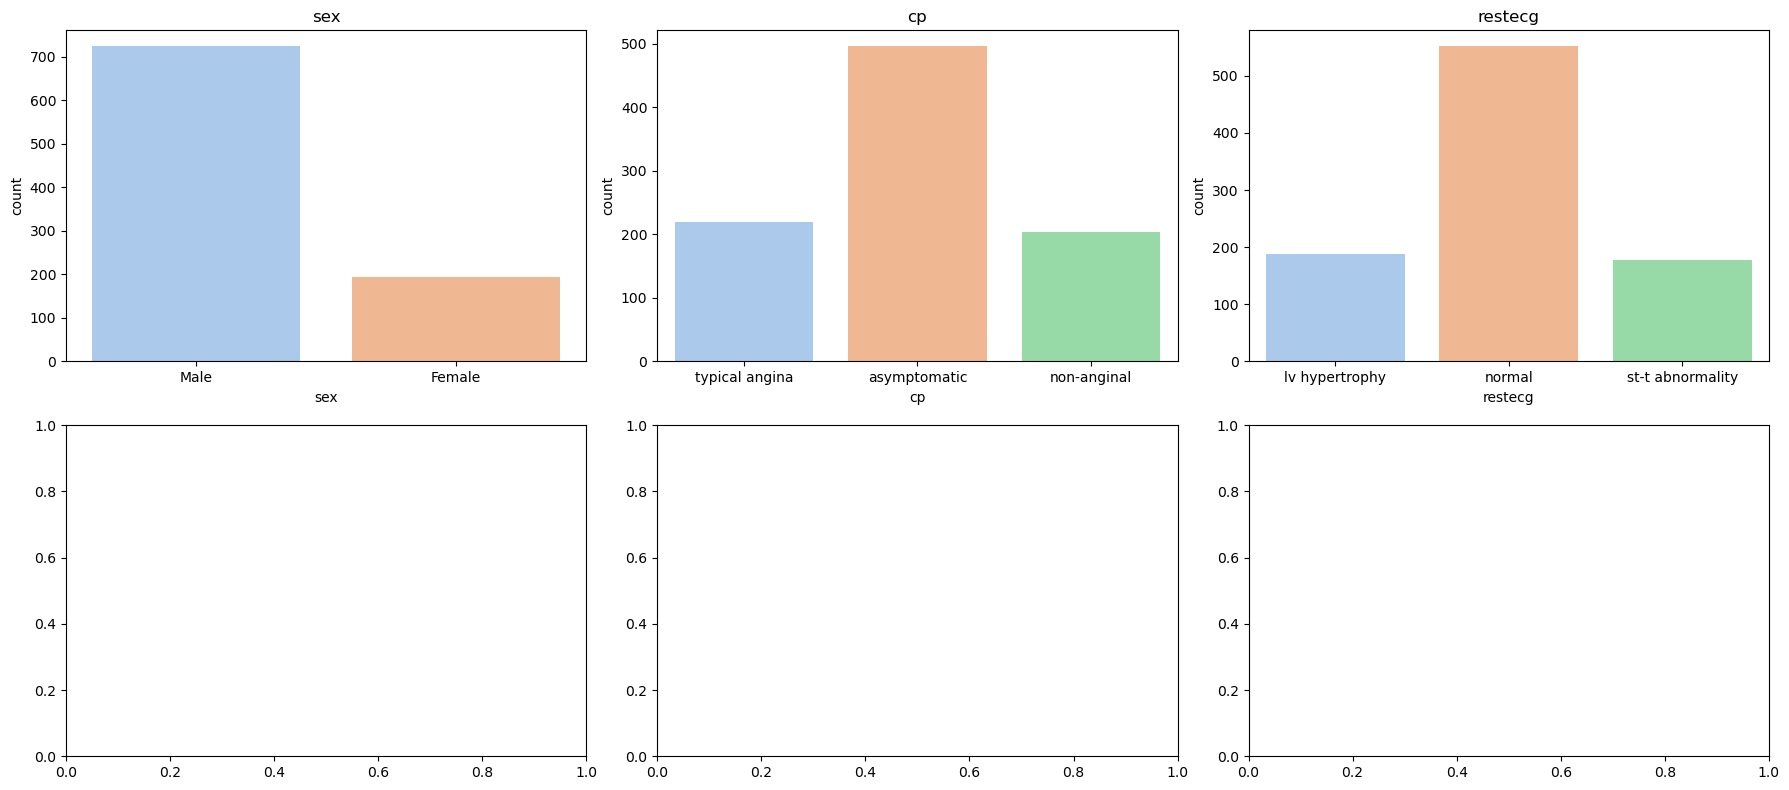

In [14]:
category_col=df.select_dtypes(include=['object']).columns
category_col=[i for i in category_col if i in df.columns]
fig, axes=plt.subplots(2, len(category_col), figsize=(18,8))
axes=axes.flatten()
for i, col in enumerate(category_col):
    sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

C:\Users\vikas\AppData\Local\Temp\ipykernel_13288\1035908669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=df['num'], data=df, palette='Set3')


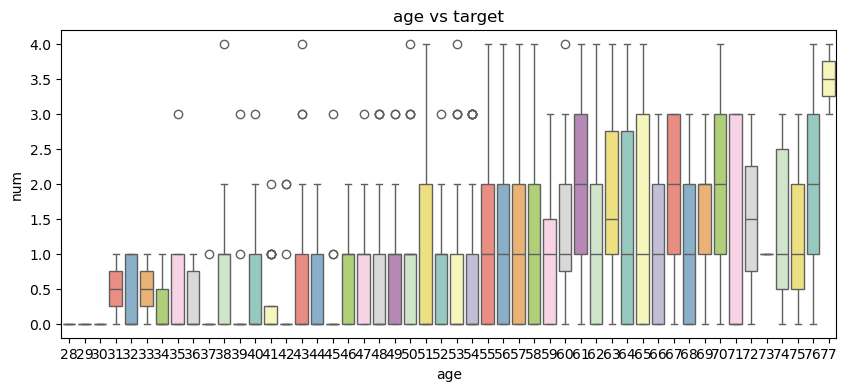

C:\Users\vikas\AppData\Local\Temp\ipykernel_13288\1035908669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=df['num'], data=df, palette='Set3')


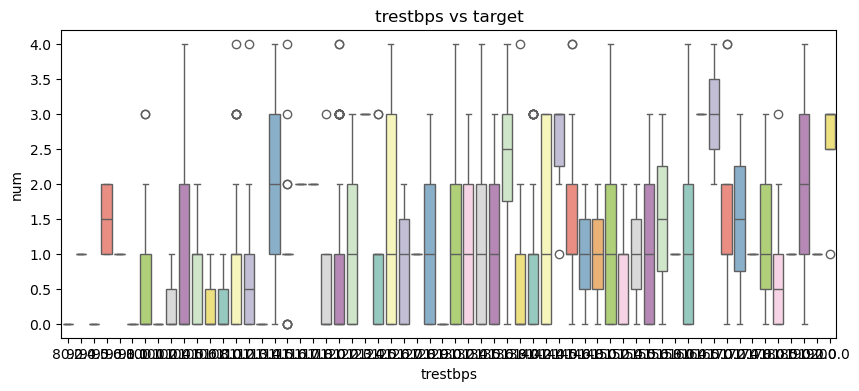

C:\Users\vikas\AppData\Local\Temp\ipykernel_13288\1035908669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=df['num'], data=df, palette='Set3')


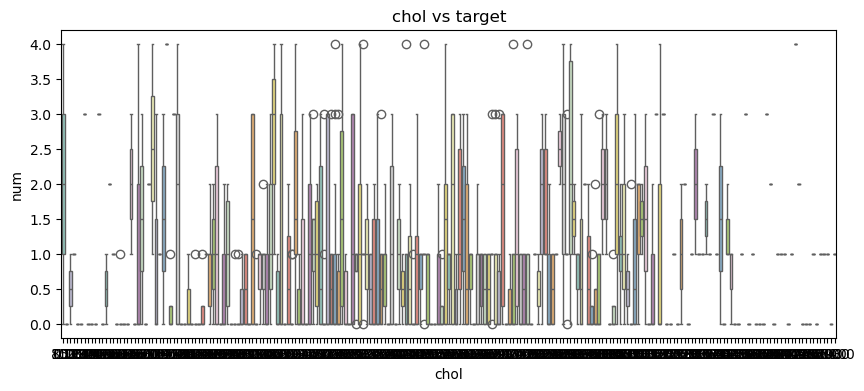

C:\Users\vikas\AppData\Local\Temp\ipykernel_13288\1035908669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=df['num'], data=df, palette='Set3')


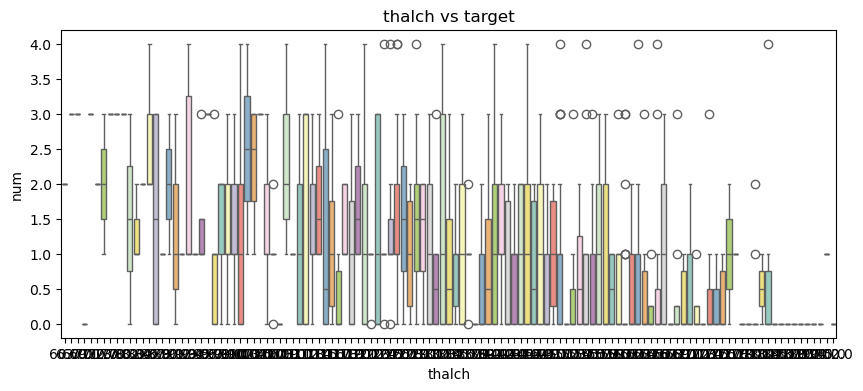

C:\Users\vikas\AppData\Local\Temp\ipykernel_13288\1035908669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=df['num'], data=df, palette='Set3')


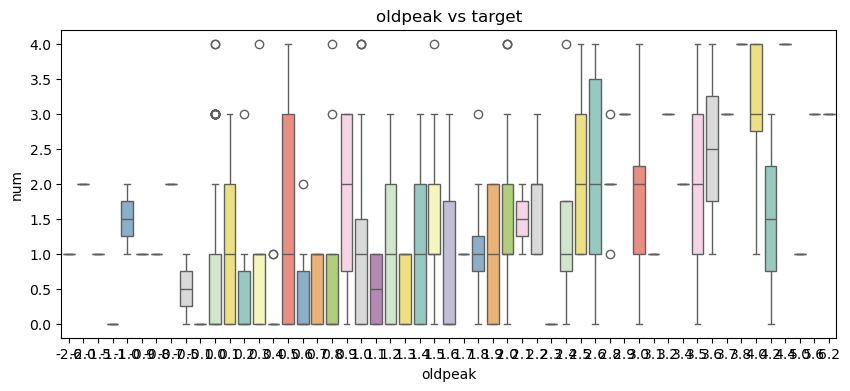

C:\Users\vikas\AppData\Local\Temp\ipykernel_13288\1035908669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=df['num'], data=df, palette='Set3')


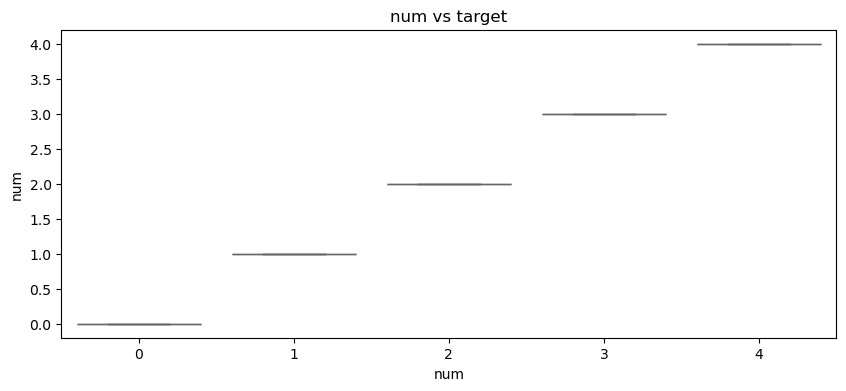

In [15]:
for col in numeric_col:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=col, y=df['num'], data=df, palette='Set3')
    plt.title(f'{col} vs target')
    plt.show()

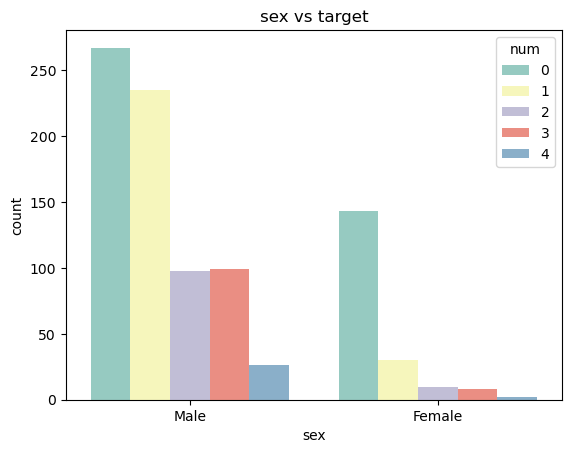

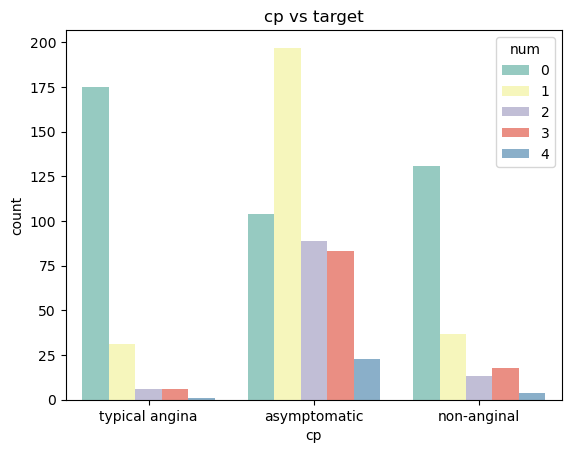

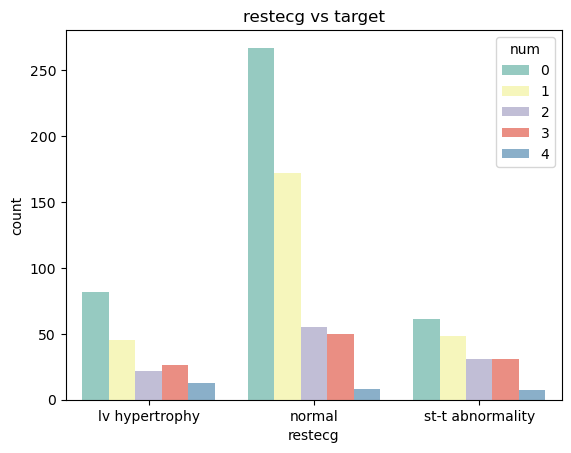

In [16]:
for col in category_col:
    plt.figure()
    sns.countplot(x=col, hue=df['num'], data=df, palette='Set3')
    plt.title(f'{col} vs target')
    plt.show()

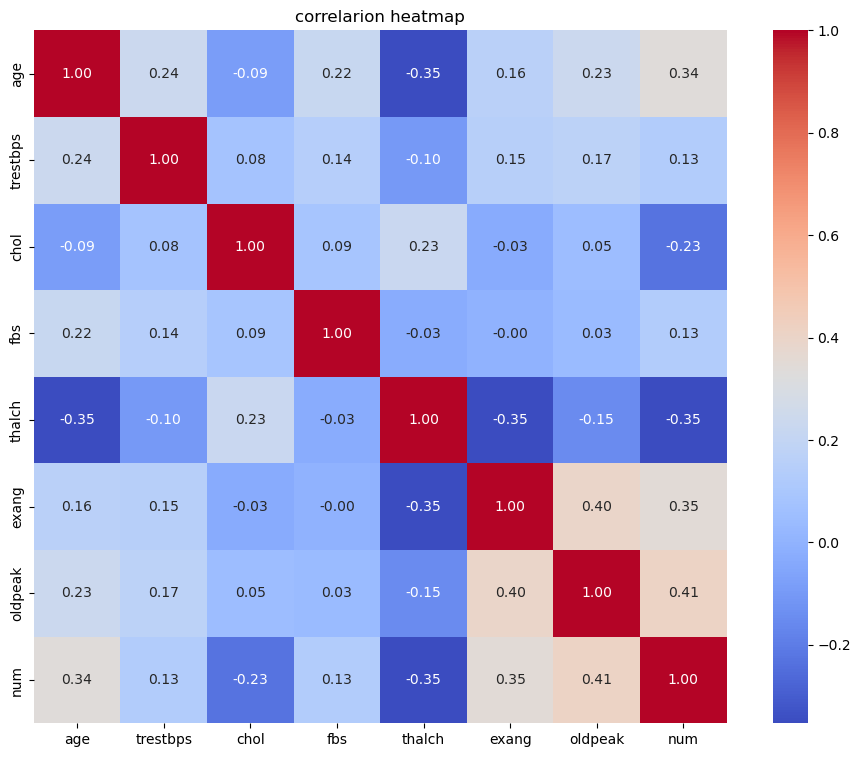

In [17]:
plt.figure(figsize=(12,9))
corr=df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('correlarion heatmap')
plt.show()

In [18]:
print("correlation with target", corr['num'].sort_values(ascending=True))

correlation with target thalch     -0.348138
chol       -0.230708
trestbps    0.128469
fbs         0.129675
age         0.339053
exang       0.349318
oldpeak     0.412231
num         1.000000
Name: num, dtype: float64


In [19]:
cols=['trestbps', 'chol', 'oldpeak']
mask=pd.Series([True] * len(df))
for col in cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    mask &= df[col].between(lower, upper)

df=df[mask]

In [20]:
df.shape

(701, 11)

In [45]:
df.head()

,age,trestbps,chol,thalch,oldpeak,num,sex_Male,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True
0,63,145.0,233.0,150.0,2.3,0,1,0,1,1,0,0,0
1,67,160.0,286.0,108.0,1.5,2,1,0,0,0,0,0,1
2,67,120.0,229.0,129.0,2.6,1,1,0,0,0,0,0,1
3,37,130.0,250.0,187.0,3.5,0,1,1,0,0,1,0,0
4,41,130.0,204.0,172.0,1.4,0,0,0,1,0,0,0,0


In [22]:
df=pd.get_dummies(df, columns=['sex', 'cp', 'fbs', 'restecg', 'exang'], drop_first=True, dtype=int)

In [76]:
x=df.drop(columns='num', axis=1)
y=df['num']

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [78]:
scaler=StandardScaler()
x=scaler.fit_transform(x)

In [79]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=2, stratify=y)

In [105]:
svc=SVC(kernel='sigmoid', gamma=1.0)
lr=LogisticRegression(solver='liblinear', penalty='l1')
mnb=MultinomialNB()
gnb=GaussianNB()
bnb=BernoulliNB()
dtc=DecisionTreeClassifier(max_depth=5)
knc=KNeighborsClassifier()
rfc=RandomForestClassifier(n_estimators=100, random_state=2)
abc=AdaBoostClassifier(n_estimators=100, random_state=2)
bc=BaggingClassifier(n_estimators=100, random_state=2)
etc=ExtraTreesClassifier(n_estimators=100, random_state=2)
gbc=GradientBoostingClassifier(n_estimators=100, random_state=2)
xgb=XGBClassifier(n_estimators=100, random_state=2)

In [106]:
clfs={
    'SVC':svc,
    'LR':lr,
    'GNB':gnb,
    'BNB':bnb,
    'DTC':dtc,
    'KNC':knc,
    'RFC':rfc,
    'ABC':abc,
    'BC':bc,
    'ETC':etc,
    'GBC':gbc,
    'XGB':xgb
}

In [107]:
def train_classifier(clf, x_train, y_train, x_test, y_test):
    clf.fit(x_train, y_train)
    y_pred=clf.predict(x_test)
    accuracy=accuracy_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred, average='macro')

    return accuracy, recall

In [108]:
train_classifier(svc, x_train, y_train, x_test, y_test)

(0.6382978723404256, 0.32894736842105265)

In [109]:
accuracy_scores = []
recall_scores = []

for name, clf in clfs.items():
    current_accuracy, current_recall = train_classifier(clf, x_train, y_train, x_test, y_test)
    print("for ", name)
    print("Accuracy - ", current_accuracy)
    print("Recall - ", current_recall)
    
    
    accuracy_scores.append(current_accuracy)
    recall_scores.append(current_recall)

for  SVC
Accuracy -  0.6382978723404256
Recall -  0.32894736842105265
for  LR
Accuracy -  0.6312056737588653
Recall -  0.2956140350877193
for  GNB
Accuracy -  0.48936170212765956
Recall -  0.3973684210526316
for  BNB
Accuracy -  0.6453900709219859
Recall -  0.30614035087719293
for  DTC
Accuracy -  0.5531914893617021
Recall -  0.2552631578947368
for  KNC
Accuracy -  0.5815602836879432
Recall -  0.28596491228070176


C:\Users\vikas\anaconda3\dataanv\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


for  RFC
Accuracy -  0.6453900709219859
Recall -  0.3289473684210526
for  ABC
Accuracy -  0.6312056737588653
Recall -  0.3570175438596491
for  BC
Accuracy -  0.5957446808510638
Recall -  0.3052631578947368
for  ETC
Accuracy -  0.574468085106383
Recall -  0.26929824561403504
for  GBC
Accuracy -  0.6170212765957447
Recall -  0.3096491228070175
for  XGB
Accuracy -  0.6099290780141844
Recall -  0.34649122807017546


In [111]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 10, None]}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(x_train, y_train)
print(grid.best_params_, grid.best_score_)

{'max_depth': 5, 'n_estimators': 300} 0.6410714285714285


In [114]:
y_pred_grid=grid.predict(x_test)

In [115]:
accuracy_score(y_test, y_pred_grid)

0.6312056737588653

In [116]:
import pickle
pickle.dump(grid, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))